# **1. Imports Library Umum & Konfigurasi Awal**

In [ ]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency
from tqdm.auto import tqdm
import joblib
from copy import deepcopy
import os
import shutil
from google.colab import drive
from copy import deepcopy

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)

# **2. Memuat Data**

## 2.1 Hubungkan Drive

In [ ]:
drive.mount('/content/drive', force_remount=True)
project_dir = "/content/drive/MyDrive/android-malware"

Mounted at /content/drive


## 2.2 Memuat Dataset

In [ ]:
dataset_path = "feature_vectors_syscallsbinders_frequency_5_Cat.csv"
print("Path to dataset:", dataset_path)

Path to dataset: feature_vectors_syscallsbinders_frequency_5_Cat.csv


### 2.3 Cek Data

In [ ]:
df = pd.read_csv(dataset_path)
print(f"Dataset berhasil dimuat dengan ukuran: {df.shape}\n")

target_column = 'Class'

print("DISTRIBUSI KELAS")
print(df[target_column].value_counts())

Dataset berhasil dimuat dengan ukuran: (11598, 471)

DISTRIBUSI KELAS
Class
SMS_Malware        3904
Mobile_Riskware    2546
Banking_Malware    2100
Benign             1795
Adware             1253
Name: count, dtype: int64


# **3. Exploratory Data Analysis (EDA)**


In [ ]:
TARGET_COLUMN = 'Class'
CATEGORICAL_COLS = None
DROP_COLS = None


## 3.1 Import Library untuk EDA dan Preprocessing

In [ ]:
from scipy.stats import mannwhitneyu, chi2_contingency, shapiro, kruskal
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
print("Library berhasil diimport")


Library berhasil diimport


## 3.2 Info Dasar Dataset

In [ ]:
print("=" * 60)
print("TIPE DATA & NULL")
print("=" * 60)
info_df = pd.DataFrame({
    'dtype'   : df.dtypes,
    'null'    : df.isnull().sum(),
    'null_%'  : (df.isnull().sum() / len(df) * 100).round(2),
    'unique'  : df.nunique()
})
print(info_df.to_string())


TIPE DATA & NULL
                                           dtype  null  null_%  unique
ACCESS_PERSONAL_INFO___                    int64     0     0.0     323
ALTER_PHONE_STATE___                       int64     0     0.0       4
ANTI_DEBUG_____                            int64     0     0.0      17
CREATE_FOLDER_____                         int64     0     0.0      63
CREATE_PROCESS`_____                       int64     0     0.0      43
CREATE_THREAD_____                         int64     0     0.0     200
DEVICE_ACCESS_____                         int64     0     0.0     320
EXECUTE_____                               int64     0     0.0      73
FS_ACCESS____                              int64     0     0.0     623
FS_ACCESS()____                            int64     0     0.0     137
FS_ACCESS(CREATE)____                      int64     0     0.0     239
FS_ACCESS(CREATE__APPEND)__                int64     0     0.0      11
FS_ACCESS(CREATE__READ)__                  int64     0     0

## 3.3 Distribusi Kelas Target

                 Count  Percent (%)
Class                              
SMS_Malware       3904        33.66
Mobile_Riskware   2546        21.95
Banking_Malware   2100        18.11
Benign            1795        15.48
Adware            1253        10.80

Imbalance Ratio (max/min): 3.12x
Dataset cukup imbalanced (3–10x)


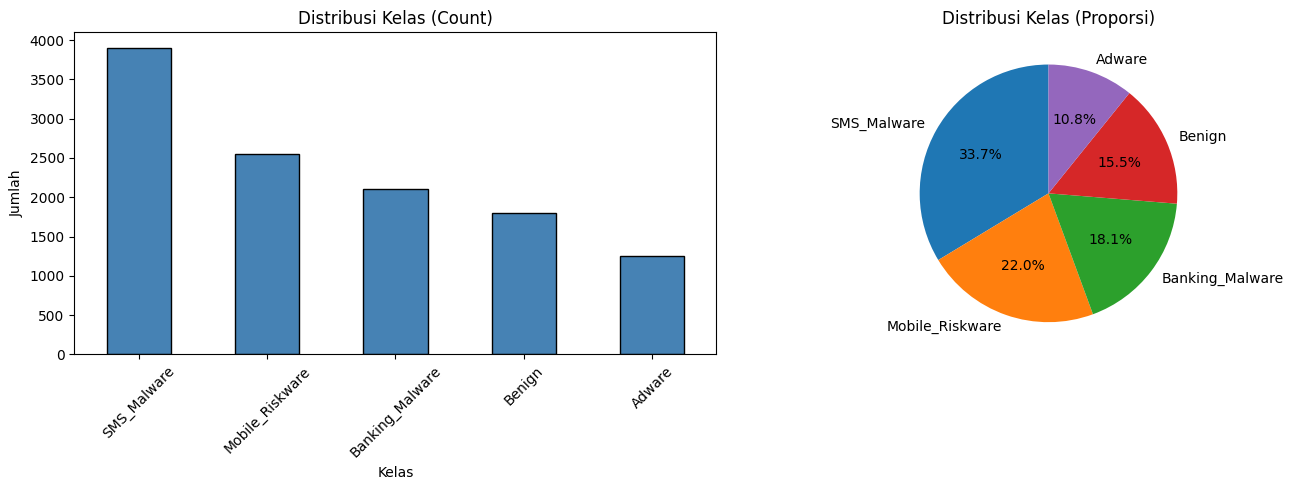

In [ ]:
vc = df[TARGET_COLUMN].value_counts()
vc_pct = df[TARGET_COLUMN].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({'Count': vc, 'Percent (%)': vc_pct.round(2)})
print(dist_df.to_string())

# Imbalance ratio
max_cls = vc.max()
min_cls = vc.min()
ratio   = max_cls / min_cls
print(f"\nImbalance Ratio (max/min): {ratio:.2f}x")
if ratio > 10:
    print("Dataset sangat imbalanced (>10x)")
elif ratio > 3:
    print("Dataset cukup imbalanced (3–10x)")
else:
    print("Dataset relatif balanced")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Kelas (Count)')
axes[0].set_xlabel('Kelas'); axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=45)

vc_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribusi Kelas (Proporsi)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('01_class_distribution.png', bbox_inches='tight')
plt.show()


## 3.4 Duplikat & Missing Values

In [ ]:
dup = df.duplicated().sum()
null_total = df.isnull().sum().sum()
print(f"Baris duplikat : {dup} ({dup/len(df)*100:.2f}%)")
print(f"Total null     : {null_total}")

null_cols = df.isnull().sum()
null_cols = null_cols[null_cols > 0].sort_values(ascending=False)
if len(null_cols):
    print("\nKolom dengan missing values:")
    print(null_cols.to_string())
else:
    print("Tidak ada missing values")


Baris duplikat : 72 (0.62%)
Total null     : 0
Tidak ada missing values


## 3.5 Statistik Deskriptif Fitur Numerik

In [ ]:
num_df = df.select_dtypes(include='number').drop(columns=[TARGET_COLUMN], errors='ignore')
desc = num_df.describe().T
desc['skewness'] = num_df.skew().round(3)
desc['kurtosis'] = num_df.kurt().round(3)
desc['cv (%)']   = (num_df.std() / num_df.mean().abs() * 100).round(2)
print(desc.to_string())


                                            count          mean           std  min    25%     50%      75%        max  skewness   kurtosis    cv (%)
ACCESS_PERSONAL_INFO___                   11598.0     57.435334    444.149233  0.0    0.0     2.0     8.00     7647.0    11.220    138.827    773.30
ALTER_PHONE_STATE___                      11598.0      0.001207      0.055703  0.0    0.0     0.0     0.00        5.0    69.795   5797.896   4614.57
ANTI_DEBUG_____                           11598.0      0.044577      1.104287  0.0    0.0     0.0     0.00       91.0    54.639   4075.221   2477.28
CREATE_FOLDER_____                        11598.0      5.781342     10.380946  0.0    2.0     3.0     6.00      700.0    32.411   1933.604    179.56
CREATE_PROCESS`_____                      11598.0      0.983877      4.061886  0.0    0.0     0.0     0.00      140.0    11.923    275.173    412.85
CREATE_THREAD_____                        11598.0     29.770391     32.170379  0.0   10.0    17.0    39.00

## 3.5 Deteksi Outlier (IQR)

In [ ]:
num_df = df.select_dtypes(include='number').drop(columns=[TARGET_COLUMN], errors='ignore')

outlier_summary = []
for col in num_df.columns:
    Q1, Q3 = num_df[col].quantile(0.25), num_df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((num_df[col] < Q1 - 1.5*IQR) | (num_df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({'Feature': col, 'Outlier Count': outliers, 'Outlier %': round(outliers/len(df)*100, 2)})

out_df = pd.DataFrame(outlier_summary).sort_values('Outlier %', ascending=False)
print(out_df[out_df['Outlier Count'] > 0].to_string(index=False))
print(f"\n{(out_df['Outlier Count'] == 0).sum()} fitur tanpa outlier")


                                 Feature  Outlier Count  Outlier %
                                  sendto           2775      23.93
                  sendAccessibilityEvent           2674      23.06
                          setInTouchMode           2576      22.21
                     FS_ACCESS(READ)____           2454      21.16
                               sigaction           2395      20.65
                                   flock           2369      20.43
                    NETWORK_ACCESS()____           2319      19.99
                          getInTouchMode           2288      19.73
                                fchown32           2263      19.51
                                   lseek           2203      18.99
                                   wait4           2167      18.68
                                pwrite64           2165      18.67
                 getWifiServiceMessenger           2164      18.66
                                  execve           2161      1

## 3.6 Korelasi Fitur Numerik

159 pasang fitur dengan korelasi > 0.9:
                    Feature A                                Feature B  Correlation
         ALTER_PHONE_STATE___                    updateServiceLocation       1.0000
           CREATE_THREAD_____                                    clone       1.0000
         CREATE_PROCESS`_____                                     fork       1.0000
                 EXECUTE_____                                   execve       1.0000
                     setgid32                                 setuid32       1.0000
             setPlaybackState                  setTransportControlInfo       1.0000
                  setMetadata                  setTransportControlInfo       1.0000
       sched_get_priority_max                   sched_get_priority_min       1.0000
               sched_getparam                       sched_getscheduler       1.0000
                  setMetadata                         setPlaybackState       1.0000
                 isSyncActive       

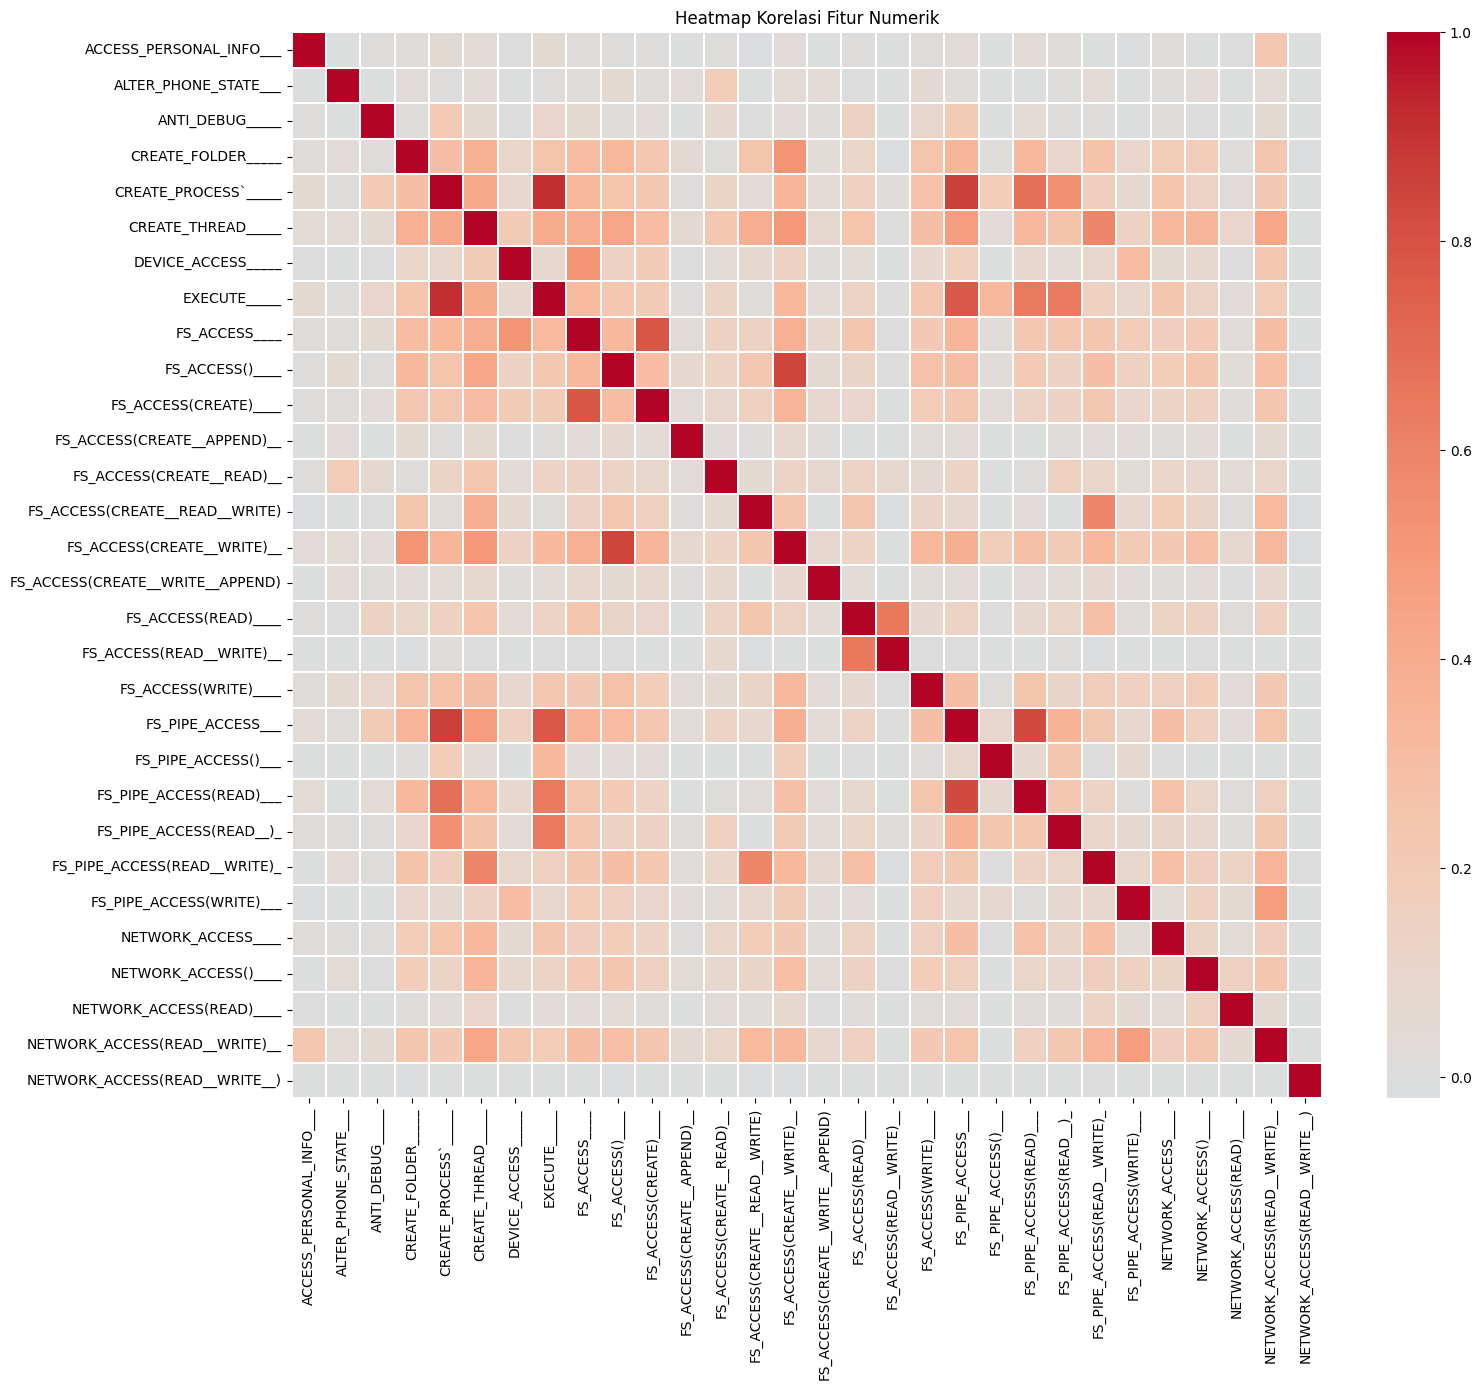

In [ ]:
num_df = df.select_dtypes(include='number').drop(columns=[TARGET_COLUMN], errors='ignore')
corr = num_df.corr()

high_corr = []
for i, j in combinations(corr.columns, 2):
    v = corr.loc[i, j]
    if abs(v) > 0.9:
        high_corr.append({'Feature A': i, 'Feature B': j, 'Correlation': round(v, 4)})

if high_corr:
    print(f"{len(high_corr)} pasang fitur dengan korelasi > 0.9:")
    print(pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False).to_string(index=False))
else:
    print("Tidak ada pasangan fitur dengan korelasi > 0.9")

# Heatmap
cols_plot = num_df.columns[:30]
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(num_df[cols_plot].corr(), cmap='coolwarm', center=0,
            xticklabels=True, yticklabels=True, ax=ax, linewidths=0.3)
ax.set_title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', bbox_inches='tight')
plt.show()


## 3.7 Seleksi Fitur


In [ ]:
from scipy.stats import tiecorrect
import numpy as np

num_df = df.select_dtypes(include='number').drop(columns=[TARGET_COLUMN], errors='ignore')
kw_results = []
skipped = []

for col in num_df.columns:
    groups = [group[col].values for _, group in df.groupby(TARGET_COLUMN)]
    alldata = np.concatenate(groups)

    if len(set(alldata)) <= 1:
        skipped.append(col)
        continue

    try:
        stat, p = kruskal(*groups)
        kw_results.append({'Feature': col, 'H-stat': round(stat, 4), 'p-value': p, 'Signifikan': p < 0.05})
    except ValueError:
        skipped.append(col)

if skipped:
    print(f"{len(skipped)} kolom dilewati (nilai identik): {skipped}")

kw_df = pd.DataFrame(kw_results).sort_values('p-value')
keep_num = kw_df[kw_df['Signifikan']]['Feature'].tolist()
drop_num = kw_df[~kw_df['Signifikan']]['Feature'].tolist()
print(f"Numerik dipertahankan : {len(keep_num)}")
print(f"Numerik dibuang       : {len(drop_num)} → {drop_num}")


if CATEGORICAL_COLS:
    cat_cols = [c for c in CATEGORICAL_COLS if c in df.columns]
else:
    cat_cols = df.select_dtypes(include='object').drop(columns=[TARGET_COLUMN], errors='ignore').columns.tolist()

chi_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df[TARGET_COLUMN])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi_results.append({'Feature': col, 'Chi2': round(chi2, 4), 'p-value': p, 'Signifikan': p < 0.05})

if chi_results:
    chi_df = pd.DataFrame(chi_results).sort_values('p-value')
    keep_cat = chi_df[chi_df['Signifikan']]['Feature'].tolist()
    drop_cat = chi_df[~chi_df['Signifikan']]['Feature'].tolist()
    print(f"\nKategorikal dipertahankan : {len(keep_cat)}")
    print(f"Kategorikal dibuang       : {len(drop_cat)} → {drop_cat}")
else:
    keep_cat = []
    print("\nTidak ada kolom kategorikal yang dideteksi")

keep_features = keep_num + keep_cat

Numerik dipertahankan : 400
Numerik dibuang       : 70 → ['removeActiveAdmin', 'NETWORK_ACCESS(READ__WRITE__)', 'getDataActivity', 'getPermissionGroupInfo', 'getVibrateSetting', 'queryContentProviders', 'setsid', 'setgid32', 'setuid32', 'isScanAlwaysAvailable', 'setStreamVolume', 'FS_PIPE_ACCESS()___', 'getAppWidgetInfo', 'hasNamedWallpaper', 'getSyncAutomatically', 'getWifiApConfiguration', 'removePrimaryClipChangedListener', 'removeStatusChangeListener', 'onChange', 'reassociate', 'pingSupplicant', 'unregisterRemoteControlClient', 'playSoundEffectVolume', 'partiallyUpdateAppWidgetIds', 'hasIccCard', 'isSyncActive', 'isPackageAvailable', 'hasClipboardText', 'sendExtraCommand', 'setWifiApConfiguration', 'startWifiDisplayScan', 'setMetadata', 'add', 'cancelSync', 'timer_settime', 'startBluetoothSco', 'setTransportControlInfo', 'getCameraDisabled', 'setNightMode', 'engineShown', 'getInstallLocation', 'getIsSyncable', 'setPrimaryClip', 'getLastInputMethodSubtype', 'setPlaybackState', 'fst

## 3.8 Distribusi Fitur Numerik

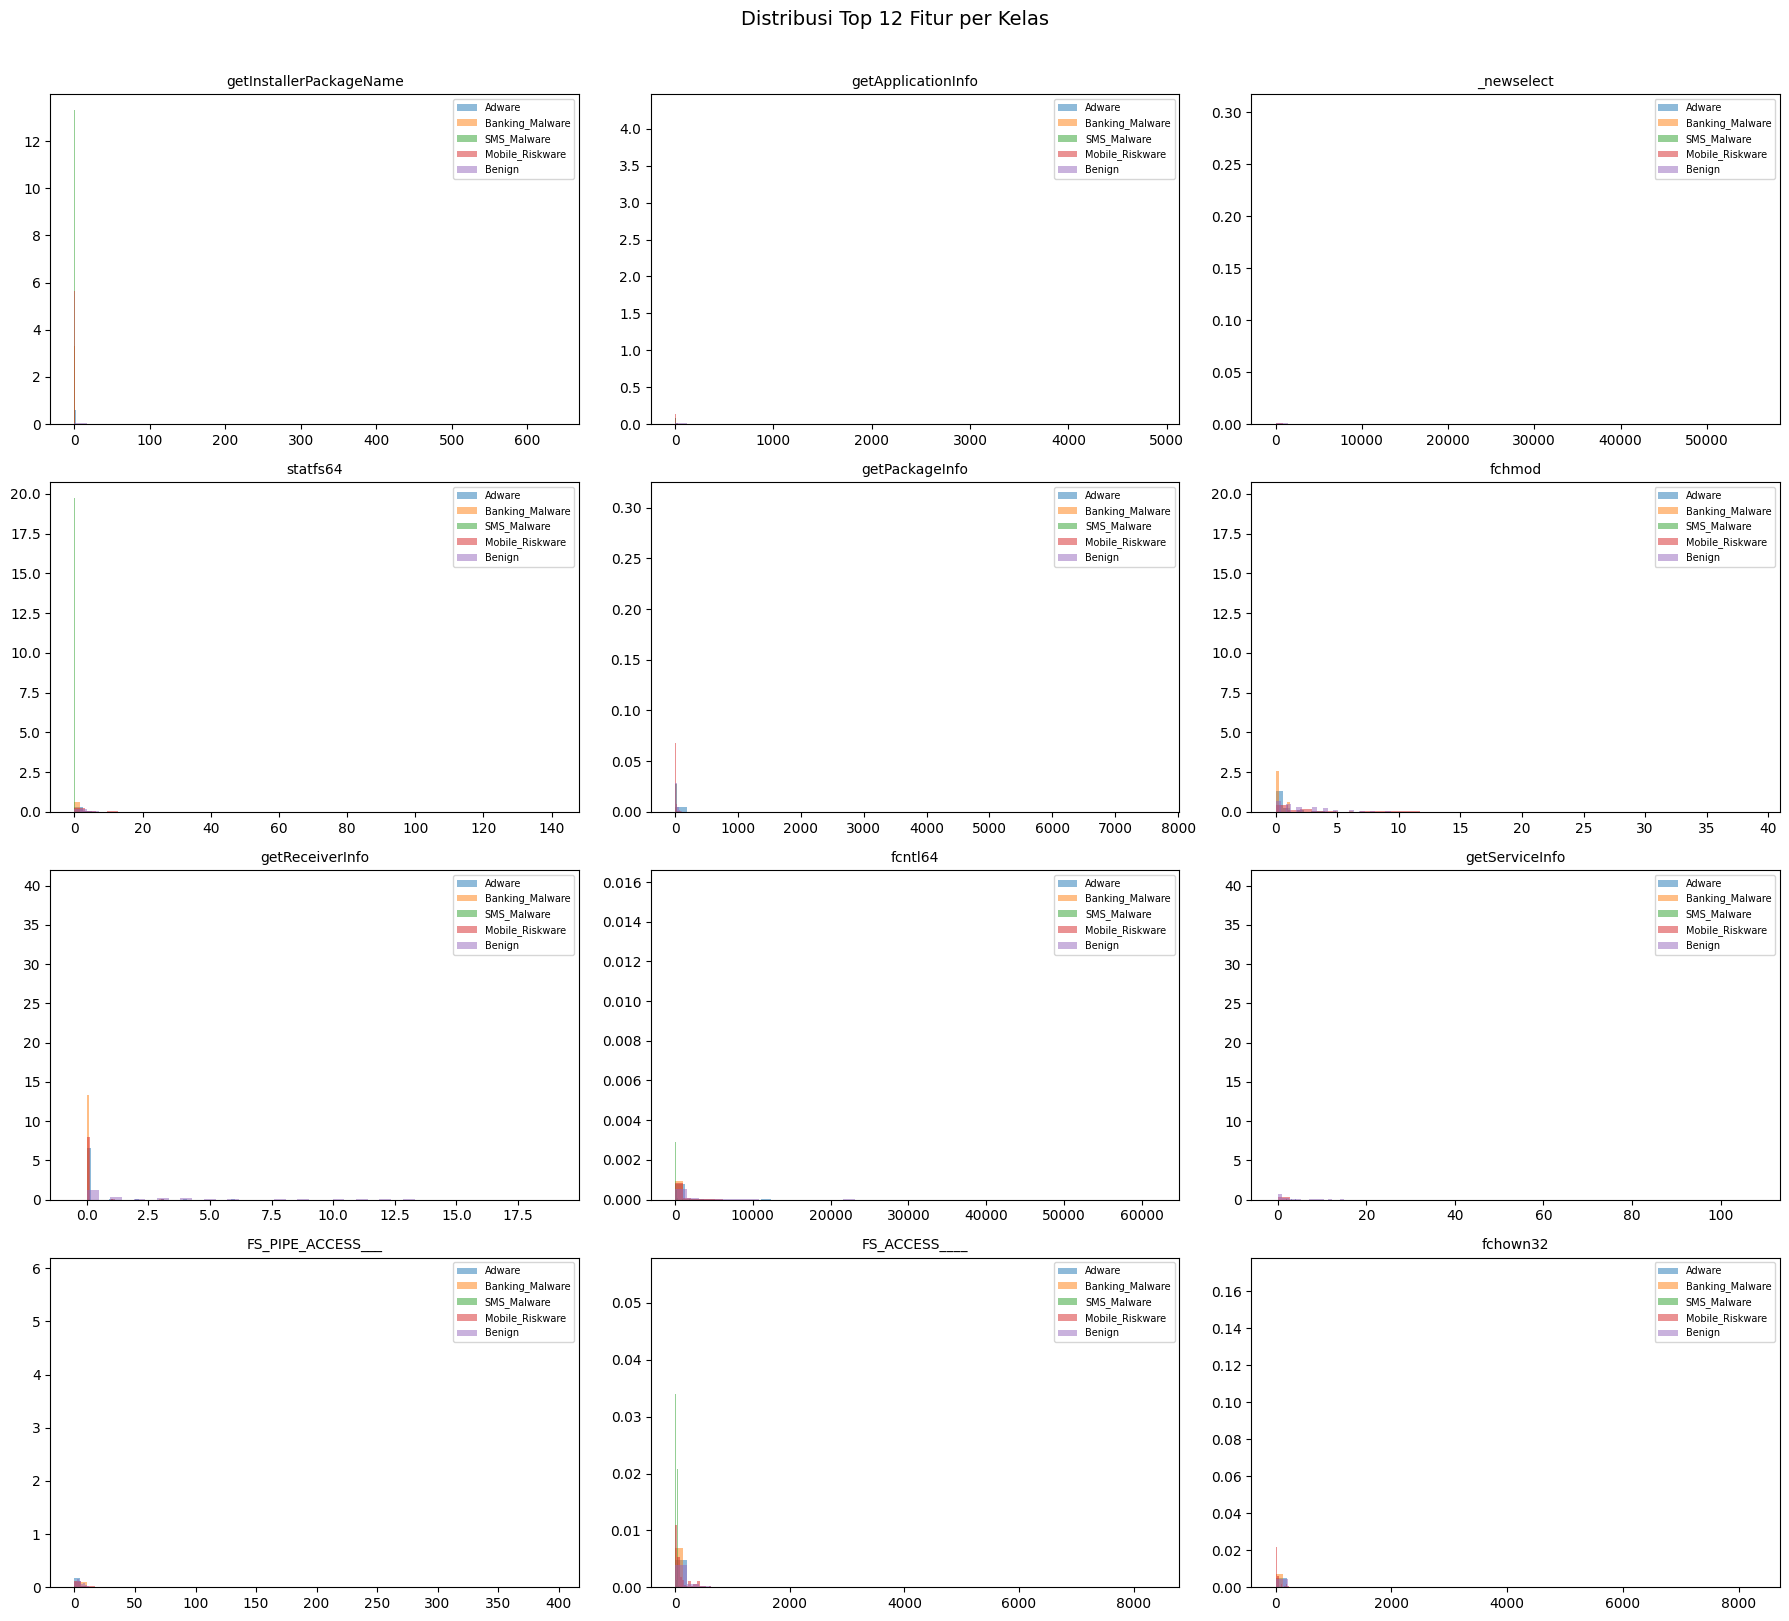

In [ ]:
top_feats = kw_df.sort_values('H-stat', ascending=False).head(12)['Feature'].tolist()

n = len(top_feats)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for idx, feat in enumerate(top_feats):
    for cls in df[TARGET_COLUMN].unique():
        subset = df[df[TARGET_COLUMN] == cls][feat]
        axes[idx].hist(subset, bins=40, alpha=0.5, label=str(cls), density=True)
    axes[idx].set_title(feat, fontsize=10)
    axes[idx].legend(fontsize=7)

for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distribusi Top 12 Fitur per Kelas', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('04_feature_distribution_per_class.png', bbox_inches='tight')
plt.show()


# **4.Data Cleaning**

## 4.1 Membersihkan Spasi pada Nama Kolom

In [ ]:
df.columns = df.columns.str.strip()

## 4.2 Menghapus Kolom yang Tidak Diperlukan

In [ ]:
df.columns = df.columns.str.strip()
print(f"Jumlah kolom setelah cleaning nama: {len(df.columns)}")

Jumlah kolom setelah cleaning nama: 471


# **5. Penanganan Missing Values & Duplicates**

## 5.1 Pengecekan Ukuran Data Awal

In [ ]:
print("Original DataFrame:")
print(df.shape)

null_rows = df[df.isnull().any(axis=1)]

print("Rows to be dropped:")
print(null_rows.index)

Original DataFrame:
(11598, 471)
Rows to be dropped:
Index([], dtype='int64')


## 5.2 Hapus Baris Kosong & Duplikat

In [ ]:
df = df.dropna()
df = df.drop_duplicates()

## 5.3 Pengecekan Ukuran Data Setelah Pembersihan

In [ ]:
print("Resulting DataFrame:")
print(df.shape)

Resulting DataFrame:
(11526, 471)


# **6. Konversi Tipe Data**

In [ ]:
print("Tipe data fitur:")
print(df.drop(columns=[TARGET_COLUMN]).dtypes.value_counts())

Tipe data fitur:
int64    470
Name: count, dtype: int64


# **7. Ekstraksi Fitur**

In [ ]:
def ip_to_decimal(ip):
    octets = ip.split('.')
    binary = '{0:08b}{1:08b}{2:08b}{3:08b}'.format(*map(int, octets))
    decimal = int(binary, 2)
    return decimal

# **8. Encoding Target Multiclass & Pembersihan Akhir**

## 8.1 Import LabelEncoder & Cek Distribusi Label Asli

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
print("Distribusi label asli:")
print(df['Class'].value_counts())
print(f"\nTotal kelas: {df['Class'].nunique()}")

Distribusi label asli:
Class
SMS_Malware        3903
Mobile_Riskware    2534
Banking_Malware    2044
Benign             1792
Adware             1253
Name: count, dtype: int64

Total kelas: 5


## 8.2 Label Encoding & Mapping Kelas

In [ ]:
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Class'])

class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping kelas:")
for cls, idx in class_mapping.items():
    print(f"  {idx} = {cls}")

Mapping kelas:
  0 = Adware
  1 = Banking_Malware
  2 = Benign
  3 = Mobile_Riskware
  4 = SMS_Malware


## 8.3 Visualisasi Distribusi Kelas

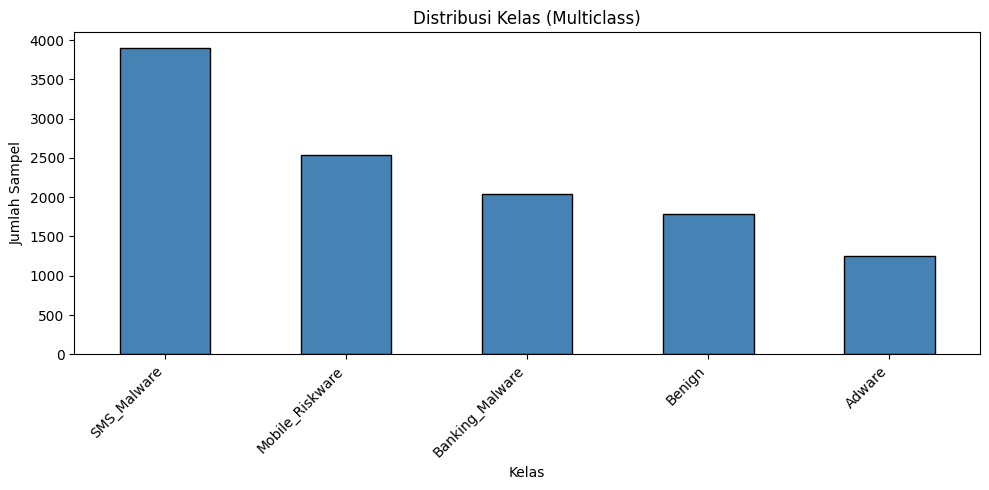

In [ ]:
plt.figure(figsize=(10, 5))
df['Class'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Kelas (Multiclass)')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

## 8.4 Menghapus Kolom Asli Setelah Feature Engineering

In [ ]:
df = df.drop(columns=['Class'])
print(f"Shape setelah drop kolom 'Class': {df.shape}")

Shape setelah drop kolom 'Class': (11526, 471)


# **9. Analisis Distribusi & Uji Statistik Fitur**

## 9.1 Visualisasi Histogram Distribusi Fitur

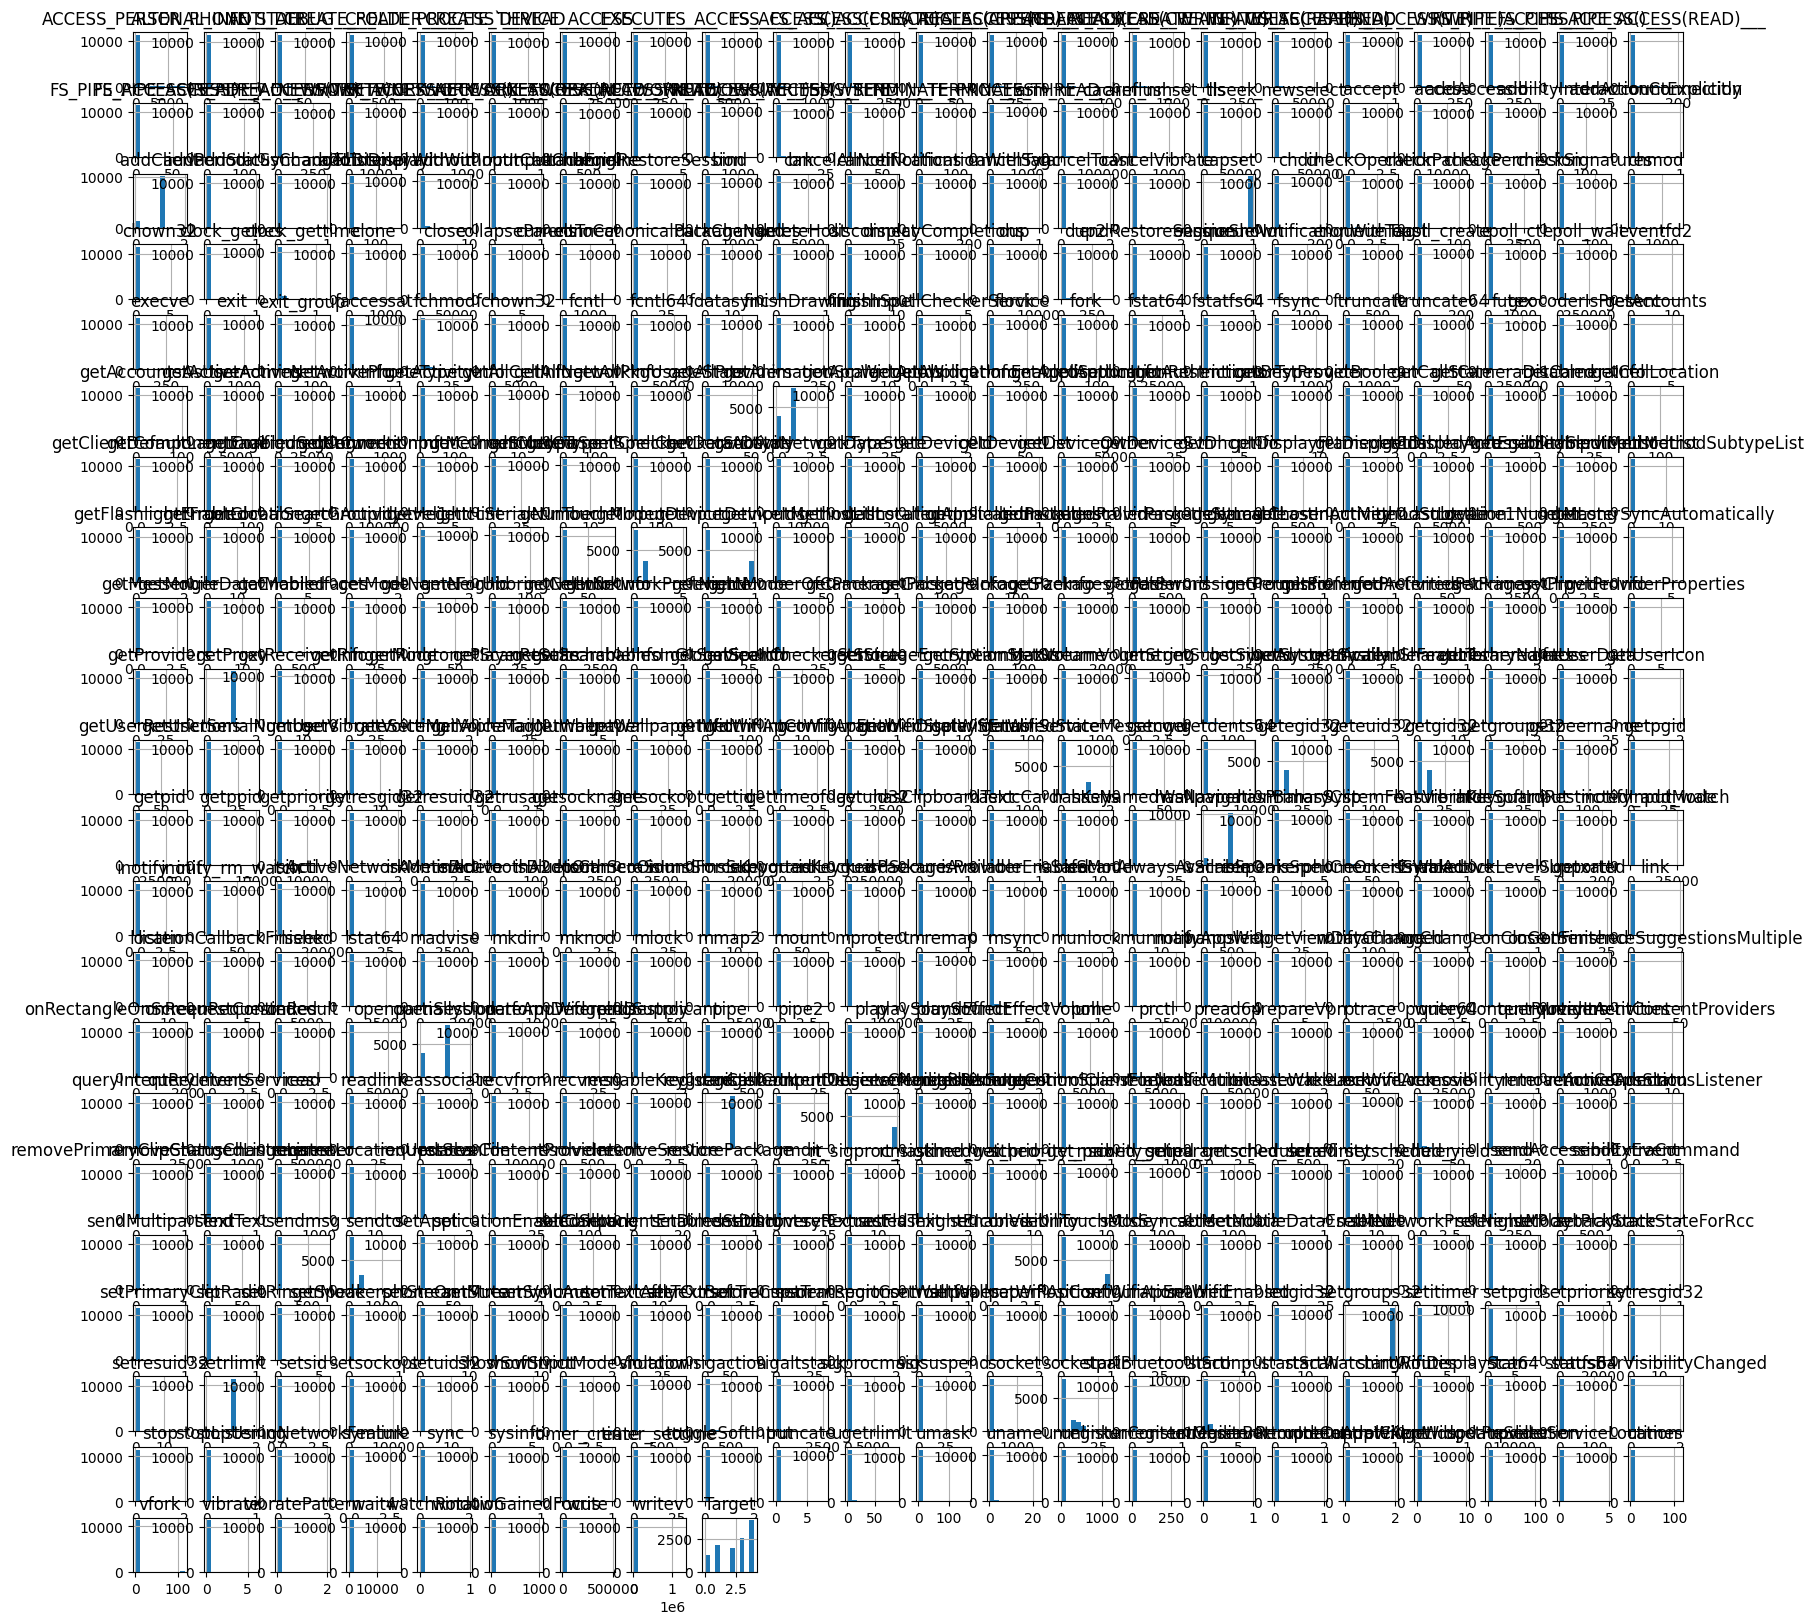

In [ ]:
df.hist(figsize=(20, 20))
plt.tight_layout()
plt.show()

## 9.2 Seleksi Fitur Numerikal

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns.drop('Target')

keep_num_features = set()
exclude_num_features = set()

for col in numeric_cols:
    significant = False
    classes = df['Target'].unique()
    for cls in classes:
        group_a = df.loc[df['Target'] == cls, col]
        group_b = df.loc[df['Target'] != cls, col]
        stat, p = mannwhitneyu(group_a, group_b)
        if p < 0.05:
            significant = True
            break
    if significant:
        keep_num_features.add(col)
    else:
        exclude_num_features.add(col)

print(f"Fitur numerik dipertahankan: {len(keep_num_features)}")
print(f"Fitur numerik dibuang: {len(exclude_num_features)}")
print("\nDibuang:", exclude_num_features)

Fitur numerik dipertahankan: 453
Fitur numerik dibuang: 17

Dibuang: {'link', 'queryContentProviders', 'symlink', 'FS_ACCESS(READ__WRITE)__', 'getLastChosenActivity', 'lgetxattr', 'getNameForUid', 'getresgid32', 'getGroupIdLevel1', 'mount', 'faccessat', 'setExtractedText', 'fcntl', 'chown32', 'isScanAlwaysAvailable', 'getresuid32', 'registerSuggestionSpansForNotification'}


## 9.3 Seleksi Fitur Kategorikal

In [ ]:
object_cols = df.select_dtypes(include='object').columns

keep_cat_df = pd.DataFrame(columns=['Feature', 'Chi2 Statistic', 'p-value'])
exclude_cat_df = pd.DataFrame(columns=['Feature', 'Chi2 Statistic', 'p-value'])

for col in object_cols:
    contingency_table = pd.crosstab(df[col], df['Target'])
    chi2, p, dof, _ = chi2_contingency(contingency_table)
    if p < 0.05:
        keep_cat_df = pd.concat([keep_cat_df, pd.DataFrame({'Feature': [col], 'Chi2 Statistic': [chi2], 'p-value': [p.round(5)]})], ignore_index=True)
    else:
        exclude_cat_df = pd.concat([exclude_cat_df, pd.DataFrame({'Feature': [col], 'Chi2 Statistic': [chi2], 'p-value': [p.round(3)]})], ignore_index=True)

print("Features to keep:")
print(keep_cat_df)
print("\nFeatures to exclude:")
print(exclude_cat_df)

Features to keep:
Empty DataFrame
Columns: [Feature, Chi2 Statistic, p-value]
Index: []

Features to exclude:
Empty DataFrame
Columns: [Feature, Chi2 Statistic, p-value]
Index: []


# **10. Memisahkan Fitur (X) dan Target (y)**

In [ ]:
keep_features = list(keep_num_features) + list(keep_cat_df.Feature)

targ_var = 'Target'
X = df[keep_features]
y = df[targ_var]

print(f"Shape X: {X.shape}")
print(f"Jumlah kelas: {y.nunique()}")

Shape X: (11526, 453)
Jumlah kelas: 5


# 10.1 Mutual Information Post-Cleaning

Menghitung Mutual Information terhadap target...

  TOP 20 FITUR — MUTUAL INFORMATION (Post-Cleaning)
Rank   Feature                                  MI Score
-------------------------------------------------------
1      gettimeofday                             0.628252
2      pread64                                  0.614539
3      mmap2                                    0.588754
4      open                                     0.579142
5      munmap                                   0.567584
6      access                                   0.567472
7      fcntl64                                  0.562723
8      close                                    0.549700
9      stat64                                   0.546956
10     sigprocmask                              0.545261
11     read                                     0.529064
12     fstat64                                  0.526258
13     gettid                                   0.523445
14     getpid                               

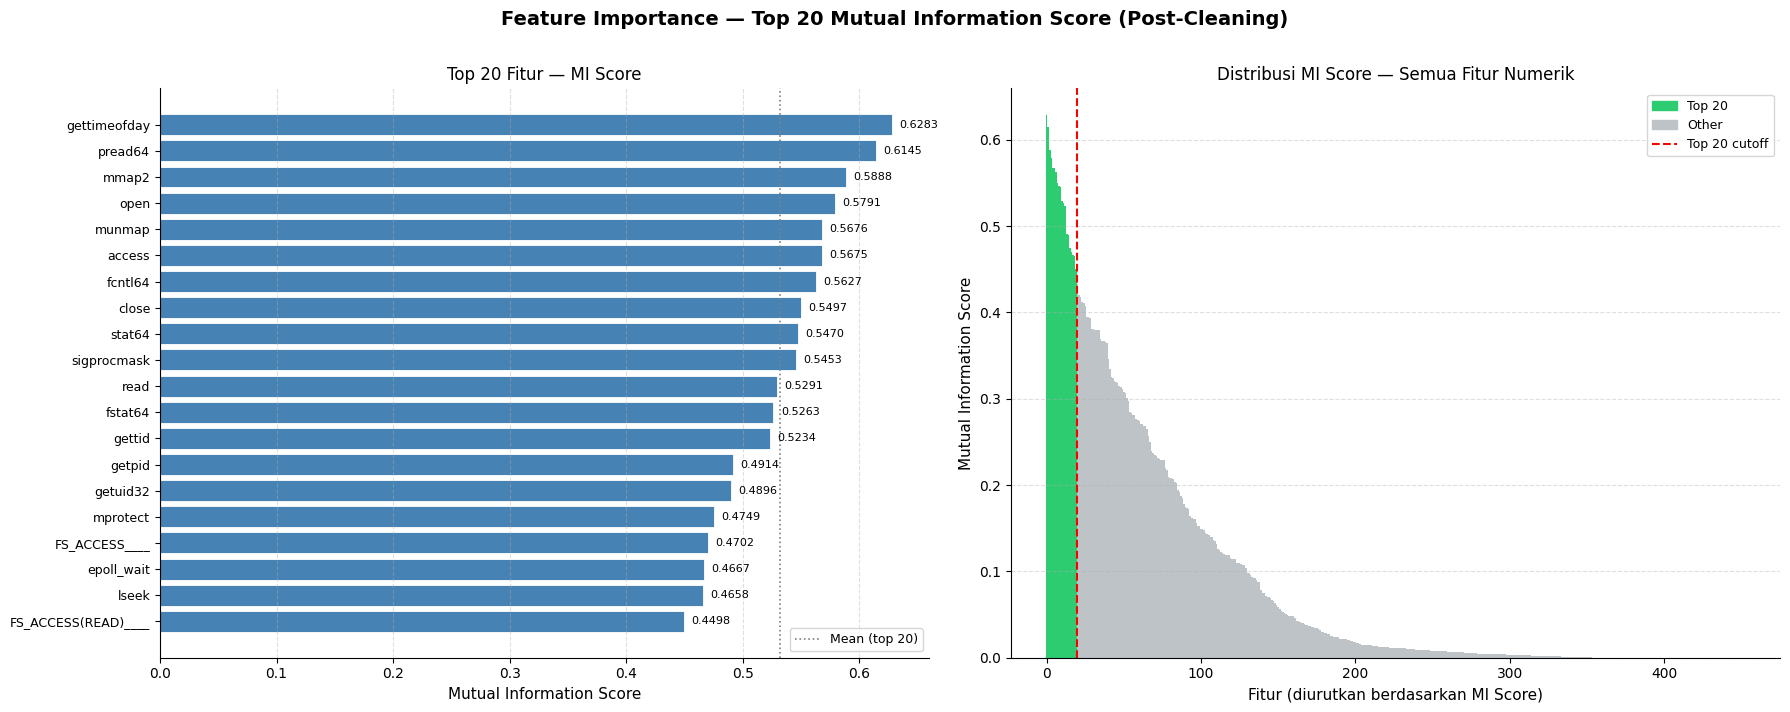

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TOP_N = 20

num_cols_fs = X.select_dtypes(include='number').columns.tolist()

X_num_fs = X[num_cols_fs].values.astype(float)
X_num_fs = np.where(np.isinf(X_num_fs), np.nan, X_num_fs)
X_num_fs = SimpleImputer(strategy='median').fit_transform(X_num_fs)

# Drop kolom zero-variance
var_mask = X_num_fs.var(axis=0) > 0
X_num_fs_clean = X_num_fs[:, var_mask]
clean_cols_fs  = [c for c, v in zip(num_cols_fs, var_mask) if v]

if var_mask.sum() < len(num_cols_fs):
    dropped = [c for c, v in zip(num_cols_fs, var_mask) if not v]
    print(f"[INFO] {len(dropped)} kolom zero-variance di-skip: {dropped}")

print("Menghitung Mutual Information terhadap target...")
mi_scores = mutual_info_classif(X_num_fs_clean, y, random_state=RANDOM_STATE)

mi_df = pd.DataFrame({
    'Feature' : clean_cols_fs,
    'MI Score': mi_scores.round(6)
}).sort_values('MI Score', ascending=False).reset_index(drop=True)
mi_df.index += 1

top20_mi = mi_df.head(TOP_N)

print(f"\n{'='*55}")
print(f"  TOP {TOP_N} FITUR — MUTUAL INFORMATION (Post-Cleaning)")
print(f"{'='*55}")
print(f"{'Rank':<6} {'Feature':<38} {'MI Score':>10}")
print("-" * 55)
for rank, row in top20_mi.iterrows():
    print(f"{rank:<6} {row['Feature']:<38} {row['MI Score']:>10.6f}")
print("-" * 55)
print(f"Total fitur numerik dianalisis : {len(clean_cols_fs)}")
print(f"Rata-rata MI Score             : {mi_scores.mean():.6f}")
print(f"Fitur dengan MI < 0.01         : {(mi_scores < 0.01).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    f'Feature Importance — Top {TOP_N} Mutual Information Score (Post-Cleaning)',
    fontsize=14, fontweight='bold', y=1.01
)

palette = plt.cm.RdYlGn(np.linspace(0.2, 0.9, TOP_N))[::-1]
bars = axes[0].barh(
    top20_mi['Feature'][::-1],
    top20_mi['MI Score'][::-1],
    color='steelblue', edgecolor='white', linewidth=0.6
)
for bar, score in zip(bars, top20_mi['MI Score'][::-1]):
    axes[0].text(
        bar.get_width() + top20_mi['MI Score'].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{score:.4f}', va='center', ha='left', fontsize=8
    )
axes[0].set_xlabel('Mutual Information Score', fontsize=11)
axes[0].set_title(f'Top {TOP_N} Fitur — MI Score', fontsize=12)
axes[0].tick_params(axis='y', labelsize=9)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='x', linestyle='--', alpha=0.4)
axes[0].axvline(top20_mi['MI Score'].mean(), color='gray',
                linestyle=':', linewidth=1.2, label='Mean (top 20)')
axes[0].legend(fontsize=9)

sorted_all = mi_df['MI Score'].values
colors_all = ['#2ecc71' if i < TOP_N else '#bdc3c7' for i in range(len(sorted_all))]
axes[1].bar(range(len(sorted_all)), sorted_all, color=colors_all, width=1.0, edgecolor='none')
axes[1].axvline(TOP_N - 0.5, color='red', linestyle='--', linewidth=1.5, label=f'Top {TOP_N} cutoff')
axes[1].set_xlabel('Fitur (diurutkan berdasarkan MI Score)', fontsize=11)
axes[1].set_ylabel('Mutual Information Score', fontsize=11)
axes[1].set_title('Distribusi MI Score — Semua Fitur Numerik', fontsize=12)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
selected_patch = mpatches.Patch(color='#2ecc71', label=f'Top {TOP_N}')
rest_patch     = mpatches.Patch(color='#bdc3c7', label='Other')
axes[1].legend(handles=[selected_patch, rest_patch, axes[1].lines[0]], fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance_MI.png', bbox_inches='tight', dpi=150)
plt.show()

# **11. Import Library Machine Learning**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, fbeta_score, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
from tqdm import tqdm

# **12. Split Data & Definisi Jenis Kolom**

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

categorical_cols = []
numeric_cols = list(keep_features)
print(f"Jumlah fitur numerik: {len(numeric_cols)}")
print(f"Jumlah fitur kategorikal: {len(categorical_cols)}")

Jumlah fitur numerik: 453
Jumlah fitur kategorikal: 0


# **13. Inisialisasi Model Random Forest, XGBoost, dan Linear SVM**

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

classifiers = [
    ('RandomForestClassifier', RandomForestClassifier(random_state=42)),
    ('XGBClassifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')),
    ('SVMLinearClassifier', CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=2000)))
]

# **14. Konfigurasi Preprocessor, Sampler, dan Metrik**

In [ ]:
# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols)
], remainder='passthrough')

# Sampler
sampler = SMOTE(random_state=42)

# Metrik
scoring = {
    'fbeta': make_scorer(fbeta_score, beta=2, average='weighted'),
    'f1'   : make_scorer(f1_score, average='weighted'),
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall'   : make_scorer(recall_score, average='weighted'),
    'accuracy' : make_scorer(accuracy_score)
}

# **15. Proses Training dengan Cross-Validation & Simpan Model Terbaik**

,Classifier,CV F2 Score,CV F1,CV Recall,CV Precision,CV Accuracy
1,XGBClassifier,0.948358,0.948453,0.948373,0.948922,0.948373
0,RandomForestClassifier,0.943433,0.943679,0.943492,0.944967,0.943492
2,SVMLinearClassifier,0.859463,0.859404,0.860304,0.862644,0.860304



=== CONFUSION MATRIX TIAP MODEL ===


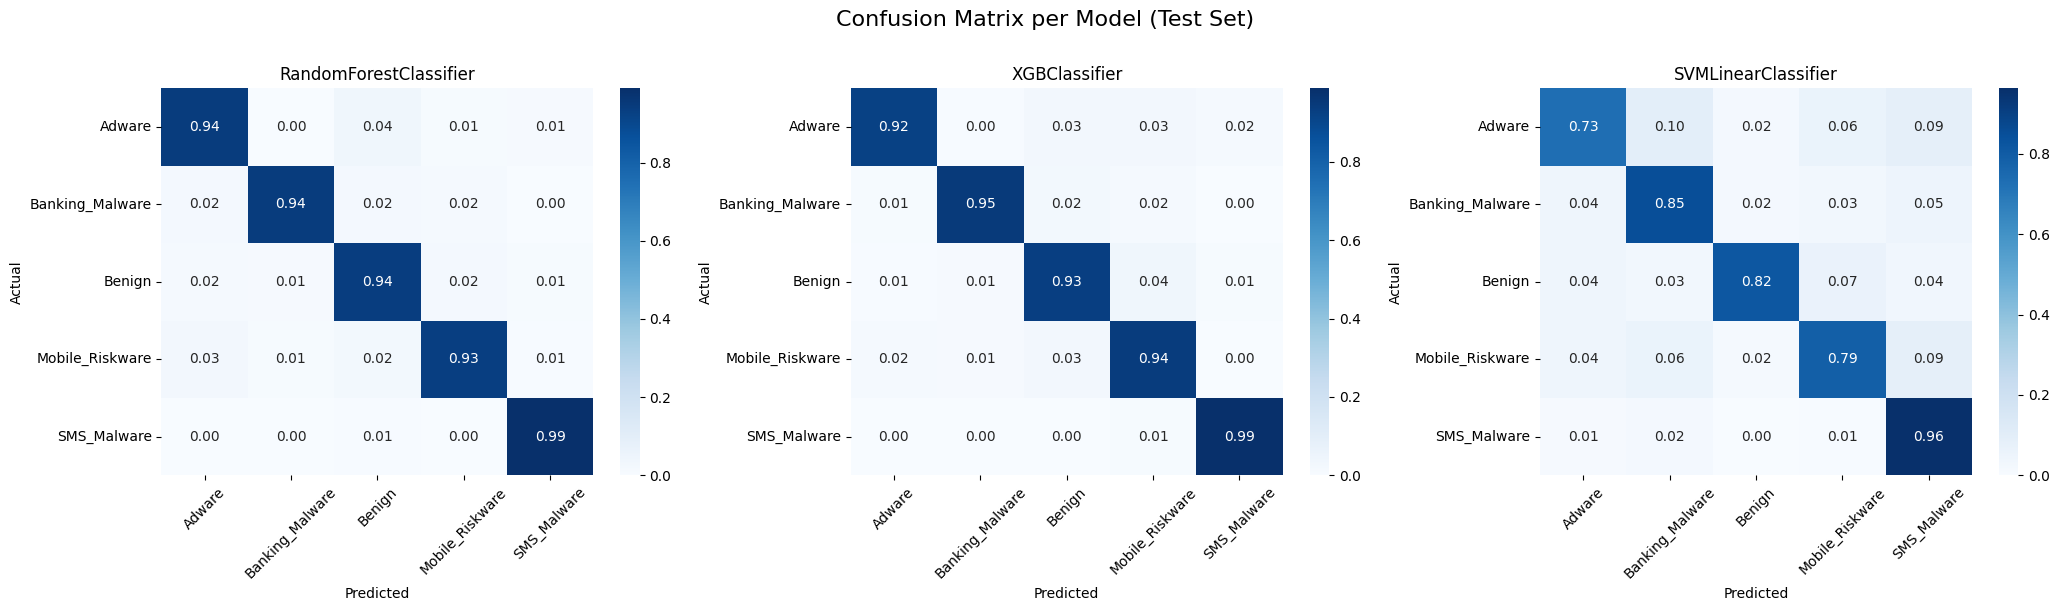

Confusion matrix per model telah disimpan.


In [ ]:
best_pipeline = None
best_score = -np.inf
results = []
trained_pipelines = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for clf_name, classifier in tqdm(classifiers, desc='Classifier', leave=False):
    pipeline = make_pipeline(preprocessor, sampler, classifier)
    cv_scores = cross_validate(pipeline, X_train, y_train, scoring=scoring, cv=cv, n_jobs=-1)

    results.append({
        'Classifier': clf_name,
        'CV F2 Score': np.mean(cv_scores['test_fbeta']),
        'CV F1': np.mean(cv_scores['test_f1']),
        'CV Recall': np.mean(cv_scores['test_recall']),
        'CV Precision': np.mean(cv_scores['test_precision']),
        'CV Accuracy': np.mean(cv_scores['test_accuracy'])
    })

    if np.mean(cv_scores['test_fbeta']) > best_score:
        best_score = np.mean(cv_scores['test_fbeta'])
        best_pipeline = pipeline

    pipeline.fit(X_train, y_train)
    trained_pipelines[clf_name] = pipeline

best_pipeline.fit(X_train, y_train)
joblib.dump(best_pipeline, 'best_pipeline.pkl')

results_df = pd.DataFrame(results)
display(results_df.sort_values('CV F2 Score', ascending=False))

print("\n=== CONFUSION MATRIX TIAP MODEL ===")
class_names = le.classes_
n_models = len(trained_pipelines)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6))
fig.suptitle("Confusion Matrix per Model (Test Set)", fontsize=16, y=1.01)

if n_models == 1:
    axes = [axes]

for ax, (clf_name, pipe) in zip(axes, trained_pipelines.items()):
    y_pred_cm = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_cm, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(clf_name, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix_per_model.png', bbox_inches='tight')
plt.show()
print("Confusion matrix per model telah disimpan.")

In [ ]:
# Classification Report
print("=== LAPORAN KLASIFIKASI TIAP MODEL ===")
class_names = le.classes_

for clf_name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    print("" + "="*60)
    print("Laporan Klasifikasi (" + clf_name + "):")
    print("="*60)
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


=== LAPORAN KLASIFIKASI TIAP MODEL ===
Laporan Klasifikasi (RandomForestClassifier):
                 precision    recall  f1-score   support

         Adware       0.89      0.94      0.92       251
Banking_Malware       0.97      0.94      0.96       409
         Benign       0.91      0.94      0.92       358
Mobile_Riskware       0.96      0.93      0.95       507
    SMS_Malware       0.99      0.99      0.99       781

       accuracy                           0.96      2306
      macro avg       0.94      0.95      0.95      2306
   weighted avg       0.96      0.96      0.96      2306

Laporan Klasifikasi (XGBClassifier):
                 precision    recall  f1-score   support

         Adware       0.94      0.92      0.93       251
Banking_Malware       0.97      0.95      0.96       409
         Benign       0.92      0.93      0.92       358
Mobile_Riskware       0.93      0.94      0.94       507
    SMS_Malware       0.99      0.99      0.99       781

       accuracy   

# **16. FLAML**

In [ ]:
!pip install flaml[automl] -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 17.8 MB/s eta 0:00:00


In [ ]:
from flaml import AutoML
from sklearn.metrics import classification_report, fbeta_score, accuracy_score, f1_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

In [ ]:
preprocessor_flaml = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols)
], remainder='passthrough')

X_train_prep_flaml = preprocessor_flaml.fit_transform(X_train)
X_test_prep_flaml  = preprocessor_flaml.transform(X_test)


smote_flaml = SMOTE(random_state=42)
X_train_resampled_flaml, y_train_resampled_flaml = smote_flaml.fit_resample(X_train_prep_flaml, y_train)

print(f"Shape X_train setelah preprocessing + SMOTE: {X_train_resampled_flaml.shape}")
print(f"Distribusi kelas setelah SMOTE:")
print(pd.Series(y_train_resampled_flaml).value_counts())


def f1_weighted_metric(X_val, y_val, estimator, labels, X_train, y_train,
                       weight_val=None, weight_train=None, *args):
    from sklearn.metrics import f1_score as _f1
    y_pred = estimator.predict(X_val)
    val_loss   = 1 - _f1(y_val,   y_pred, average="weighted")
    y_pred_tr  = estimator.predict(X_train)
    train_loss = 1 - _f1(y_train, y_pred_tr, average="weighted")
    return val_loss, {"val_loss": val_loss, "train_loss": train_loss}


automl = AutoML()

automl_settings = {
    "time_budget": 3600,
    "metric": f1_weighted_metric,
    "task": "classification",
    "eval_method": "cv",
    "n_splits": 5,
    "split_type": "stratified",
    "seed": 42,
    "verbose": 2,
    "early_stop": True,
    "skip_transform": True,
    "log_file_name": "flaml.log",
}

print("\nMemulai pencarian model terbaik dengan FLAML...")
automl.fit(X_train_resampled_flaml, y_train_resampled_flaml, **automl_settings)

print(f"\n=== HASIL OPTIMASI FLAML ===")
print(f"Model terbaik FLAML : {automl.best_estimator}")
print(f"Best config         : {automl.best_config}")
print(f"Best CV loss        : {automl.best_loss:.4f}")


y_pred_flaml = automl.predict(X_test_prep_flaml)

print("\nLaporan Klasifikasi (FLAML):")
print(classification_report(y_test, y_pred_flaml, target_names=le.classes_))

results_flaml = {
    'Best Model (FLAML)': automl.best_estimator,
    'F2 Score': fbeta_score(y_test, y_pred_flaml, beta=2, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred_flaml, average='weighted'),
    'Recall': recall_score(y_test, y_pred_flaml, average='weighted'),
    'Precision': precision_score(y_test, y_pred_flaml, average='weighted', zero_division=0),
    'Accuracy': accuracy_score(y_test, y_pred_flaml),
}
display(pd.DataFrame([results_flaml]))


Shape X_train setelah preprocessing + SMOTE: (15610, 409)
Distribusi kelas setelah SMOTE:
Target
4    3122
0    3122
3    3122
2    3122
1    3122
Name: count, dtype: int64

Memulai pencarian model terbaik dengan FLAML...


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune



=== HASIL OPTIMASI FLAML ===
Model terbaik FLAML : lgbm
Best config         : {'n_estimators': 53, 'num_leaves': 10, 'min_child_samples': 13, 'learning_rate': np.float64(0.21480951571013288), 'log_max_bin': 6, 'colsample_bytree': np.float64(0.996498378007316), 'reg_alpha': np.float64(0.002255250947893723), 'reg_lambda': np.float64(0.10239167483099826)}
Best CV loss        : 0.0398

Laporan Klasifikasi (FLAML):
                 precision    recall  f1-score   support

         Adware       0.88      0.96      0.92       250
Banking_Malware       0.96      0.94      0.95       409
         Benign       0.90      0.84      0.87       101
Mobile_Riskware       0.95      0.93      0.94       507
    SMS_Malware       0.99      1.00      0.99       781

       accuracy                           0.96      2048
      macro avg       0.94      0.93      0.93      2048
   weighted avg       0.96      0.96      0.96      2048



,Best Model (FLAML),F2 Score,F1 Score,Recall,Precision,Accuracy
0,lgbm,0.955955,0.955992,0.956055,0.956533,0.956055


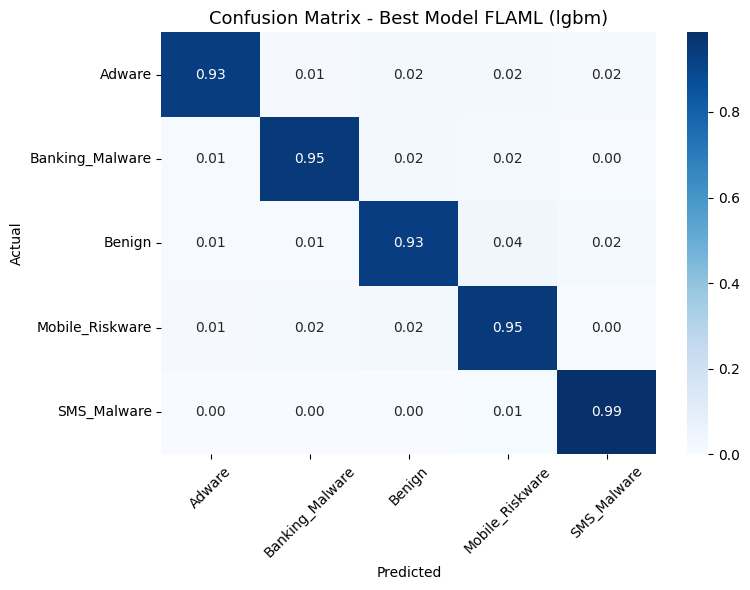

Confusion matrix FLAML best model telah disimpan.


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_names = le.classes_
best_flaml_name = automl.best_estimator
cm_flaml = confusion_matrix(y_test, y_pred_flaml, normalize="true")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_flaml, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix - Best Model FLAML (" + best_flaml_name + ")", fontsize=13)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_flaml_best.png", bbox_inches="tight")
plt.show()
print("Confusion matrix FLAML best model telah disimpan.")


# **17. AutoGluon**

In [ ]:
!pip install autogluon -q


In [ ]:
from autogluon.tabular import TabularPredictor
from sklearn.metrics import classification_report, fbeta_score, accuracy_score, f1_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE


In [ ]:
preprocessor_ag = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
], remainder='passthrough')

X_train_prep_ag = preprocessor_ag.fit_transform(X_train)
X_test_prep_ag  = preprocessor_ag.transform(X_test)


smote_ag = SMOTE(random_state=42)
X_train_resampled_ag, y_train_resampled_ag = smote_ag.fit_resample(X_train_prep_ag, y_train)

print(f"Shape X_train setelah preprocessing + SMOTE: {X_train_resampled_ag.shape}")
print(f"Distribusi kelas setelah SMOTE:")
print(pd.Series(y_train_resampled_ag).value_counts())


feature_names_out = preprocessor_ag.get_feature_names_out()
train_ag = pd.DataFrame(X_train_resampled_ag, columns=feature_names_out)
train_ag['Target'] = y_train_resampled_ag.values

test_ag = pd.DataFrame(X_test_prep_ag, columns=feature_names_out)

print("\nMemulai training dengan AutoGluon...")
predictor = TabularPredictor(
    label='Target',
    path='ag_models_multiclass/',
    eval_metric='f1_weighted',
    problem_type='multiclass'
).fit(
    train_data=train_ag,
    time_limit=3600,
    presets='best_quality',
    verbosity=2
)

print(f"\n=== HASIL OPTIMASI AUTOGLUON ===")
print(f"Model terbaik : {predictor.get_model_best()}")


print("\n=== LEADERBOARD MODEL AUTOGLUON ===")
leaderboard = predictor.leaderboard(test_ag.assign(Target=y_test.values), silent=False)
display(leaderboard)


y_pred_ag = predictor.predict(test_ag)

print("\nLaporan Klasifikasi (AutoGluon):")
print(classification_report(y_test, y_pred_ag, target_names=le.classes_))

results_ag = {
    'Best Model (AutoGluon)': predictor.get_model_best(),
    'F2 Score': fbeta_score(y_test, y_pred_ag, beta=2, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred_ag, average='weighted'),
    'Recall': recall_score(y_test, y_pred_ag, average='weighted'),
    'Precision': precision_score(y_test, y_pred_ag, average='weighted', zero_division=0),
    'Accuracy': accuracy_score(y_test, y_pred_ag),
}
display(pd.DataFrame([results_ag]))


Verbosity: 2 (Standard Logging)


Shape X_train setelah preprocessing + SMOTE: (15610, 453)
Distribusi kelas setelah SMOTE:
Target
4    3122
1    3122
3    3122
2    3122
0    3122
Name: count, dtype: int64

Memulai training dengan AutoGluon...


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       10.21 GB / 12.67 GB (80.6%)
Disk Space Avail:   75.46 GB / 107.72 GB (70.1%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will 


=== HASIL OPTIMASI AUTOGLUON ===


AttributeError: 'TabularPredictor' object has no attribute 'get_model_best'

In [ ]:
print(f"\n=== HASIL OPTIMASI AUTOGLUON ===")
print(f"Model terbaik : {predictor.model_best}")


print("\n=== LEADERBOARD MODEL AUTOGLUON ===")
leaderboard = predictor.leaderboard(test_ag.assign(Target=y_test.values), silent=False)
display(leaderboard)


y_pred_ag = predictor.predict(test_ag)

print("\nLaporan Klasifikasi (AutoGluon):")
print(classification_report(y_test, y_pred_ag, target_names=le.classes_))

results_ag = {
    'Best Model (AutoGluon)': predictor.model_best,
    'F2 Score': fbeta_score(y_test, y_pred_ag, beta=2, average='weighted'),
    'F1 Score': f1_score(y_test, y_pred_ag, average='weighted'),
    'Recall': recall_score(y_test, y_pred_ag, average='weighted'),
    'Precision': precision_score(y_test, y_pred_ag, average='weighted', zero_division=0),
    'Accuracy': accuracy_score(y_test, y_pred_ag),
}
display(pd.DataFrame([results_ag]))


=== HASIL OPTIMASI AUTOGLUON ===
Model terbaik : WeightedEnsemble_L3

=== LEADERBOARD MODEL AUTOGLUON ===
                      model  score_test  score_val  eval_metric  pred_time_test  pred_time_val     fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0           LightGBM_BAG_L2    0.964467   0.982118  f1_weighted       26.277749      42.491425  1924.451490                 0.374831                0.380356         205.779005            2       True         10
1       WeightedEnsemble_L3    0.964467   0.982118  f1_weighted       26.281806      42.499889  1926.024132                 0.004056                0.008464           1.572642            3       True         12
2         LightGBMXT_BAG_L1    0.963622   0.979867  f1_weighted       14.463185      23.577530   827.249265                14.463185               23.577530         827.249265            1       True          2
3       WeightedEnsemble_L2    0.963622   0.97986

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBM_BAG_L2,0.964467,0.982118,f1_weighted,26.277749,42.491425,1924.451490,0.374831,0.380356,205.779005,2,True,10
1,WeightedEnsemble_L3,0.964467,0.982118,f1_weighted,26.281806,42.499889,1926.024132,0.004056,0.008464,1.572642,3,True,12
2,LightGBMXT_BAG_L1,0.963622,0.979867,f1_weighted,14.463185,23.577530,827.249265,14.463185,23.577530,827.249265,1,True,2
3,WeightedEnsemble_L2,0.963622,0.979867,f1_weighted,14.469138,23.587209,828.568912,0.005953,0.009679,1.319647,2,True,7
4,LightGBMXT_BAG_L2,0.962771,0.981543,f1_weighted,27.037785,43.288304,2065.250962,1.134867,1.177235,346.578477,2,True,9
5,RandomForestGini_BAG_L2,0.961447,0.980386,f1_weighted,26.043652,45.006362,1732.100039,0.140733,2.895293,13.427554,2,True,11
6,LightGBM_BAG_L1,0.959756,0.976983,f1_weighted,6.719252,7.432449,584.787658,6.719252,7.432449,584.787658,1,True,3
7,NeuralNetFastAI_BAG_L2,0.957588,0.979293,f1_weighted,27.155524,43.231737,2009.163177,1.252605,1.120668,290.490692,2,True,8
8,ExtraTreesGini_BAG_L1,0.955953,0.970512,f1_weighted,0.624644,2.456927,6.226949,0.624644,2.456927,6.226949,1,True,6
9,RandomForestGini_BAG_L1,0.955174,0.971801,f1_weighted,1.166325,4.090863,27.407022,1.166325,4.090863,27.407022,1,True,4



Laporan Klasifikasi (AutoGluon):
                 precision    recall  f1-score   support

         Adware       0.95      0.94      0.94       251
Banking_Malware       0.97      0.95      0.96       409
         Benign       0.94      0.94      0.94       358
Mobile_Riskware       0.94      0.96      0.95       507
    SMS_Malware       0.99      0.99      0.99       781

       accuracy                           0.96      2306
      macro avg       0.96      0.96      0.96      2306
   weighted avg       0.96      0.96      0.96      2306



,Best Model (AutoGluon),F2 Score,F1 Score,Recall,Precision,Accuracy
0,WeightedEnsemble_L3,0.964432,0.964467,0.964441,0.964651,0.964441


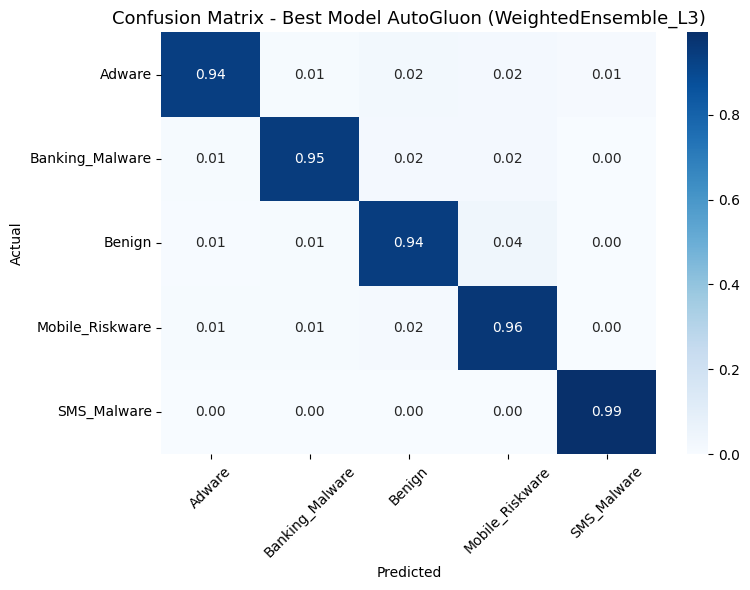

Confusion matrix AutoGluon best model telah disimpan.


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_names = le.classes_
best_ag_name = predictor.model_best
cm_ag = confusion_matrix(y_test, y_pred_ag, normalize="true")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_ag, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix - Best Model AutoGluon (" + best_ag_name + ")", fontsize=13)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_autogluon_best.png", bbox_inches="tight")
plt.show()
print("Confusion matrix AutoGluon best model telah disimpan.")
